# Photoswitching fingerprint fitting procedure

In [1]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fcs_p
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.prediction as pr
import src.analysis as an
import src.transitions as tr
import src.routines as ro

import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

import warnings


def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"


warnings.formatwarning = custom_warning_format

In [2]:
def prepare_transition_set_ofret(number_fluorophores, distance):
    fluorophores = fl.construct_fluorophores(
    name="cy5_dna", distance=distance, count=number_fluorophores, shape="square"
    )
    fluorophore_system = fl.FluorophoreSystem(fluorophores=fluorophores)

    transitions = fluorophore_system.load_transitions(
    summarize=True,
    irradiance=5,
    wavelength=640,
    bleaching=True,
    energy_transfer=True,
    dstorm=True,
    dstorm_parameters={'reducing_agent':'mea',
    'concentration':100,
    'ph':7.5},
    energy_transfer_parameters={'overwrite': {'off': [0.0001, 1]}, 
                                'exclude': ['s0', 's1', 't1', 'cis']}
    )
    transition_set = tr.TransitionSet(transitions, fluorophore_system)
    transition_set = transition_set.adjust_rates({8: 5e1})
    transition_set.finalize()

    return transition_set


In [3]:
distances = [3, 5, 6, 8]
for distance in distances:
    transition_set = prepare_transition_set_ofret(4, distance)
    fingerprint_data, bleaching_times_all_runs = \
        ro.fingerprint_analysis(transition_set, batch_size=600, batches=1, 
                                filepath=r"D:\simulation_data\bleaching_fitting\4 fluorophores", 
                                filename=f"{distance}nm", seed=1, use_memmap=r"C:\Users\vie43sq\Desktop\memmaps\run_4")

In [ ]:
distances = [3, 5, 6, 8]
for distance in distances:
    transition_set = prepare_transition_set_ofret(3, distance)
    fingerprint_data, bleaching_times_all_runs = \
        ro.fingerprint_analysis(transition_set, batch_size=600, batches=1, 
                                filepath=r"D:\simulation_data\bleaching_fitting\3 fluorophores", 
                                filename=f"{distance}nm", seed=1, use_memmap=r"C:\Users\vie43sq\Desktop\memmaps\run_1")

In [254]:
distances = [3, 5, 6, 8]
for distance in distances:
    transition_set = prepare_transition_set_ofret(2, distance)
    fingerprint_data, bleaching_times_all_runs = \
        ro.fingerprint_analysis(transition_set, batch_size=600, batches=1, 
                                filepath=r"D:\simulation_data\bleaching_fitting\2 fluorophores", 
                                filename=f"{distance}nm", seed=1, use_memmap=r"C:\Users\vie43sq\Desktop\memmaps\run_4")

### Reading the data

In [107]:
identifiers = [f"{distance}nm" for distance in distances]
bleaching_times_all = []
fingerprints_all = []

for _ in identifiers:
    fingerprints_all.append(pd.Series(np.zeros(300001), 
                                      np.round(np.linspace(0, 300, 300001), decimals=12), 
                                      dtype=np.int32))
folder_path = r"D:\simulation_data\bleaching_fitting"
for file in glob.glob(folder_path + "/*"):
    if file.endswith(".npy"):
        bleaching_times_all.append(np.load(file))
    elif file.endswith(".parquet"):
        for id in identifiers:
            if id in file:
                fingerprints_all[identifiers.index(id)] += pd.read_parquet(file).sum(axis=1)
                break

for i, fingerprint in enumerate(fingerprints_all):
    fingerprint = fingerprint.cumsum() / fingerprint.sum()
    fingerprints_all[i] = fingerprint

### Fitting the data

##### Using the bleaching times and fitting a PDF

In [116]:
parameters_all_fit_pdf = []
for bl_times in bleaching_times_all:
    parameters_all_Fs = []
    for i in range(bl_times.shape[1]):
        pi, lambda1, lambda2 = dist.estimate_mixture_parameters(
            data=bl_times[:, i][~np.isnan(bl_times[:, i])],
            initial_guess=[0.5, 1, 1.1],
            bounds=([0, 1], [0, None], [0, None]),
            truncation_low=0,
            truncation_up=300,
            number_no_events=0,#np.count_nonzero(np.isnan(bl_times[:, i])),
            method='powell', 
        )
        parameters_all_Fs.append([pi, lambda1, lambda2])    
    parameters_all_fit_pdf.append(parameters_all_Fs)

WARNING for line:  divide by zero encountered in log 
WARNING for line:             r = (xf - nfc) * (fx - ffulc)
 invalid value encountered in scalar subtract 
WARNING for line:             q = (xf - fulc) * (fx - fnfc)
 invalid value encountered in scalar subtract 
WARNING for line:             p = (xf - fulc) * q - (xf - nfc) * r
 invalid value encountered in scalar subtract 
WARNING for line:             q = 2.0 * (q - r)
 invalid value encountered in scalar subtract 


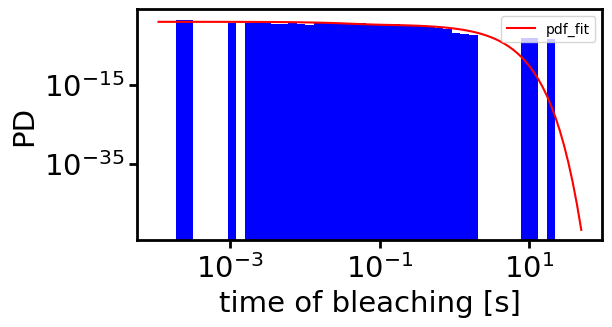

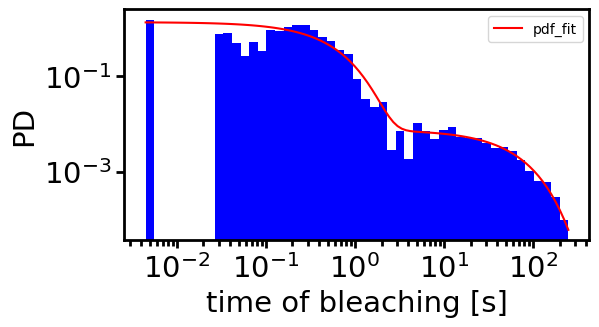

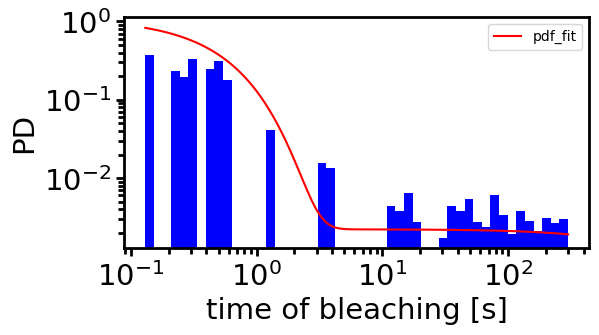

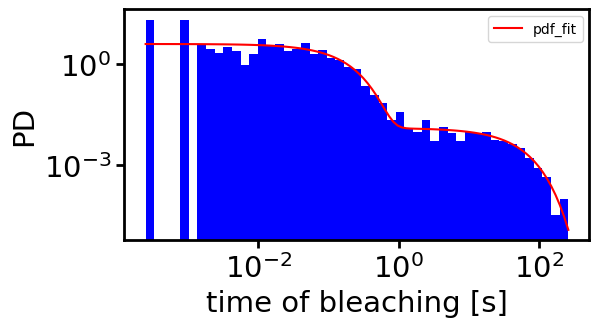

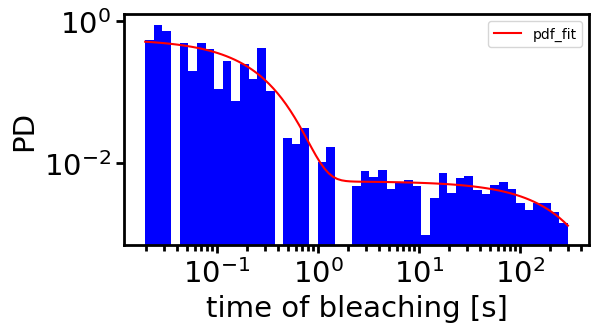

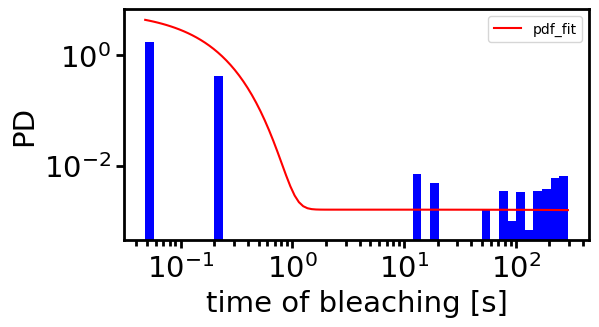

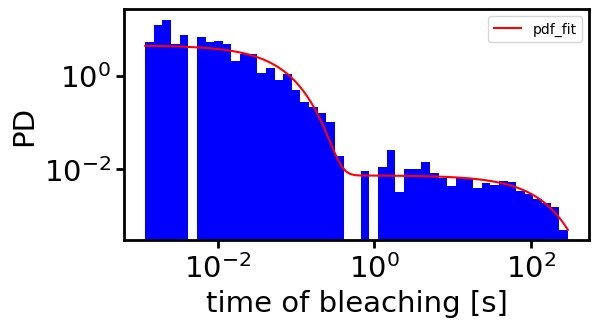

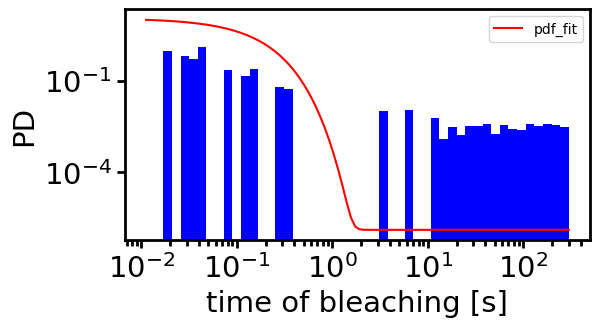

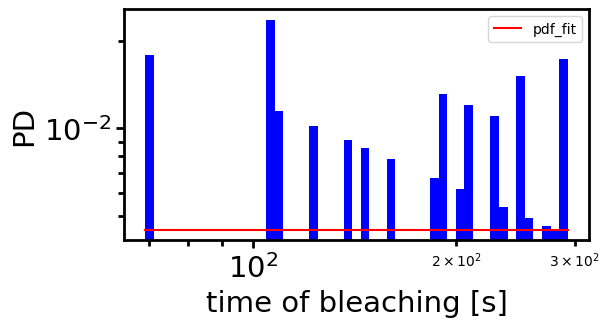

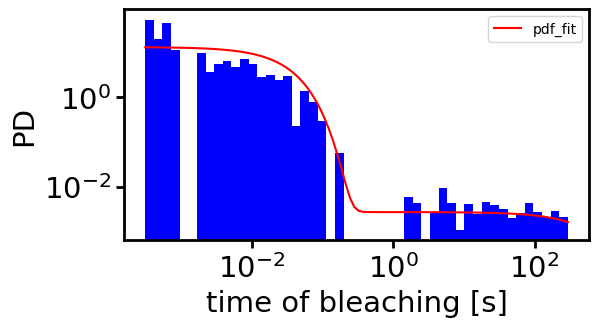

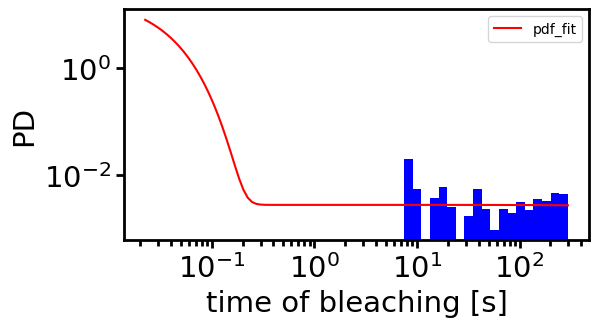

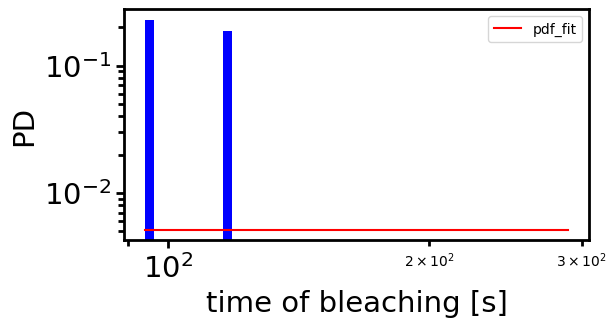

In [117]:
for (bl_times, parameters_1) in zip(bleaching_times_all, parameters_all_fit_pdf):
    for i in range(bl_times.shape[1]):
        pi_fit_1, lambda1_fit_1, lambda2_fit_1 = parameters_1[i]
        #pi_fit_2, lambda1_fit_2, lambda2_fit_2 = parameters_2[i]
        data = bl_times[:, i][~np.isnan(bl_times[:, i])]
        bins = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 50)
        ax = fi.universal_figure(type_='hist', bins=bins, data=data, density=True) 
        x = np.logspace(np.log10(np.min(data)), np.log10(np.max(data)), 100)
        # fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1_fit_2, lambda2_fit_2, pi_fit_2)], 
        #                     axes=ax[0], color='orange', label='cdf_fit')
        fi.universal_figure(data=[x, dist.two_expon_mixture_pdf(x, lambda1_fit_1, lambda2_fit_1, pi_fit_1)], 
                            type_='line', axes=ax[0], yscale='log', xscale='log', 
                            xlabel='time of bleaching [s]', ylabel='PD', color='red', label='pdf_fit', legend=True)

In [250]:
parameters_all_fit_pdf

[[[0.16829455566365206, 43.12896030098969, 2.441630913067957],
  [0.3894857084059798, 0.01920529812566642, 2.16117353431442],
  [0.8971882881081352, 0.0005002301565397686, 2.1545577688528232]],
 [[0.4782675977686426, 0.026821016824587103, 7.578993344496543],
  [0.9053972974930091, 0.004812626635598902, 4.5419768465133386],
  [0.9690475694120575, 6.417962527350826e-05, 8.11683903002585]],
 [[0.7695644227678504, 0.009033685872602129, 18.205216213493937],
  [0.953593920057187, 5.5906749134413675e-08, 9.913571065914532],
  [0.9999338930386481, 3.296911113678656e-09, 85459.45141607121]],
 [[0.8006825932563858, 0.0017515015672606208, 34.6542614244542],
  [0.988717816765064, 6.41620816250312e-05, 44.40151970269074],
  [0.9999338930386481, 3.296911113678656e-09, 85459.45141607121]]]

In [166]:
pis = []
lambdas1 = []
lambdas2 = []
for parameters in parameters_all_fit_pdf[0]:
    min_i = np.argmin(parameters[1:])
    if min_i == 1:
        lambdas1.append(parameters[1])
        lambdas2.append(parameters[2])
        pis.append(parameters[0])
    else:
        lambdas1.append(parameters[2])
        lambdas2.append(parameters[1])
        pis.append(1-parameters[0])

In [249]:
y_fit = dist.photoswitching_fingerprint_cdf(x, lambdas=[lambdas1, lambdas2], pis_orig=pis)

(2, 1)
(3, 2)
(4, 3)


array([[<Axes: title={'center': 'bleaching rate'}, xlabel='time (s)', ylabel='% emission'>]],
      dtype=object)

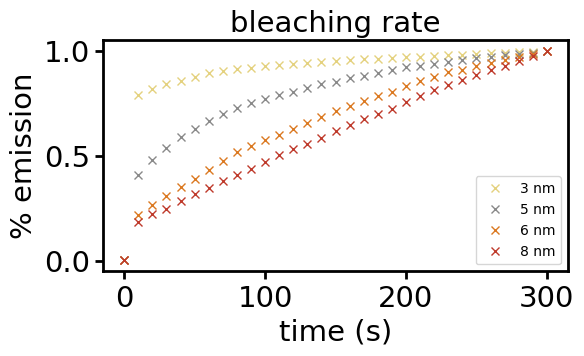

In [119]:
labels = ['3 nm', '5 nm', '6 nm', '8 nm']
colors = ['#E4D17E', '#898989', '#DB7921', '#BF3A2B']
ax = None
x = np.linspace(0, 300, 1000)
for (fingerprint, parameters, label, color) in zip(fingerprints_all, parameters_all_fit_pdf, labels, colors):
    #pi, lambda1, lambda2 = parameters
    if ax is None:
        ax = fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], label=label, color=color, marker='x', linestyle='')
    else:
        fi.universal_figure(data=[fingerprint.index[::10000], fingerprint[::10000]], axes=ax[0], label=label, color=color, marker='x', linestyle='')
    #fi.universal_figure(data=[x, dist.two_expon_mixture_cdf(x, lambda1, lambda2, pi)], axes=ax[0], color=color)
fi.universal_figure(data=[x, dist.])
fi.universal_figure(title='bleaching rate', ylabel='% emission', xlabel='time (s)', legend=True, axes=ax[0])

In [24]:
initial_params = Parameters()
initial_params.add('l1_1', value=6.29, min=6.1, max=6.4)  
initial_params.add('l2_1', value=4.6, min=4.5, max=4.7)
initial_params.add('l3_1', value=4.49, min=4.2, max=4.7)
initial_params.add('l4_2', value=0.0008, min=0.0005, max=0.0015)
initial_params.add('l1_2', value=1, vary=False)  
initial_params.add('l2_2', value=0.14, min=0.1, max=0.2)
initial_params.add('l3_2', value=0.014, min=0.01, max=0.02)
initial_params.add('pi_1', value=1, vary=False)  
initial_params.add('pi_2', value=0.996, min=0.99, max=1)
initial_params.add('pi_3', value=0.625, min=0.59, max=0.64)

In [25]:
result = model.fit(rel_all_events_distances[0], initial_params, x=np.linspace(0, 300, 300001))